# 💊 Drug Prediction Model — Random Forest
### Dataset: 1200 patients · 49 drug classes · 5 clinical features
Run each cell **one by one from top to bottom**.

## Cell 1 — Install Libraries *(run once)*

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib xgboost
import pip


!pip install xgboost

## Cell 2 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       StratifiedKFold, GridSearchCV)
from sklearn.ensemble         import (RandomForestClassifier,
                                       GradientBoostingClassifier,
                                       ExtraTreesClassifier)
from sklearn.tree             import DecisionTreeClassifier
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.metrics          import (accuracy_score, classification_report,
                                       confusion_matrix)
%pip install scikit-learn pandas numpy matplotlib seaborn joblib xgboost

print("✅ All libraries imported successfully")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
✅ All libraries imported successfully


## Cell 3 — Load Dataset

In [3]:
# ⚠️  Update this path to where your CSV file is saved
df = pd.read_csv('drug_dataset.csv')

print(f"Shape      : {df.shape}")
print(f"Columns    : {list(df.columns)}")
print(f"Null values: {df.isnull().sum().sum()} (should be 0)")
df.head()

Shape      : (1200, 11)
Columns    : ['PatientID', 'Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Year', 'Drug', 'DrugClass', 'Indication', 'DrugDescription']
Null values: 0 (should be 0)


,PatientID,Age,Sex,BP,Cholesterol,Na_to_K,Year,Drug,DrugClass,Indication,DrugDescription
0,1,57,F,HIGH,HIGH,18.155,2023,Lisinopril 10mg + Atorvastatin 20mg,ACE Inhibitor + Statin,Mid-age hypertension + dyslipidemia,Combination of ACE inhibitor Lisinopril 10mg a...
1,2,58,M,NORMAL,NORMAL,10.022,2021,Aspirin 75mg,Antiplatelet,CVD risk reduction,Low-dose antiplatelet used for long-term cardi...
2,3,88,M,NORMAL,HIGH,24.031,2020,Rosuvastatin 40mg,High-Intensity Statin,Elderly high-risk dyslipidemia,Very high-intensity statin for maximum LDL red...
3,4,69,M,HIGH,NORMAL,13.539,2025,Amlodipine 5mg,Calcium Channel Blocker,Elderly isolated hypertension,"Standard therapeutic dose of Amlodipine, a fir..."
4,5,47,F,NORMAL,HIGH,25.381,2024,Ezetimibe 10mg,Cholesterol Absorption Inhibitor,Statin-intolerant dyslipidemia,Cholesterol absorption inhibitor that selectiv...


## Cell 4 — Explore the Data

In [4]:
print("=" * 50)
print("NUMERICAL FEATURES")
print("=" * 50)
print(df[['Age', 'Na_to_K']].describe().round(2))

print("\n" + "=" * 50)
print("CATEGORICAL FEATURES")
print("=" * 50)
for col in ['Sex', 'BP', 'Cholesterol']:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())

print("\n" + "=" * 50)
print("TARGET — Drug")
print("=" * 50)
print(f"Unique drugs : {df['Drug'].nunique()}")
print(f"Min samples  : {df['Drug'].value_counts().min()}")
print(f"Max samples  : {df['Drug'].value_counts().max()}")
print("\nTop 10 drugs:")
print(df['Drug'].value_counts().head(10).to_string())

NUMERICAL FEATURES
           Age  Na_to_K
count  1200.00  1200.00
mean     53.23    22.23
std      20.43     9.41
min       5.00     6.20
25%      37.00    13.91
50%      55.00    22.31
75%      68.00    30.40
max      89.00    38.40

CATEGORICAL FEATURES

Sex:
Sex
M    608
F    592

BP:
BP
NORMAL    581
HIGH      384
LOW       235

Cholesterol:
Cholesterol
HIGH      680
NORMAL    520

TARGET — Drug
Unique drugs : 49
Min samples  : 3
Max samples  : 64

Top 10 drugs:
Drug
Rosuvastatin 20mg + Fenofibrate 145mg    64
Atorvastatin 40mg                        62
Rosuvastatin 40mg                        52
Ezetimibe 10mg                           52
Omega-3 Fatty Acids 1000mg               51
Levothyroxine 50mcg                      45
Cholestyramine 4g                        44
Ramipril 5mg + Atorvastatin 10mg         39
Amlodipine 10mg + Atorvastatin 40mg      38
Rosuvastatin 10mg                        36


## Cell 5 — Visualise Feature Distributions

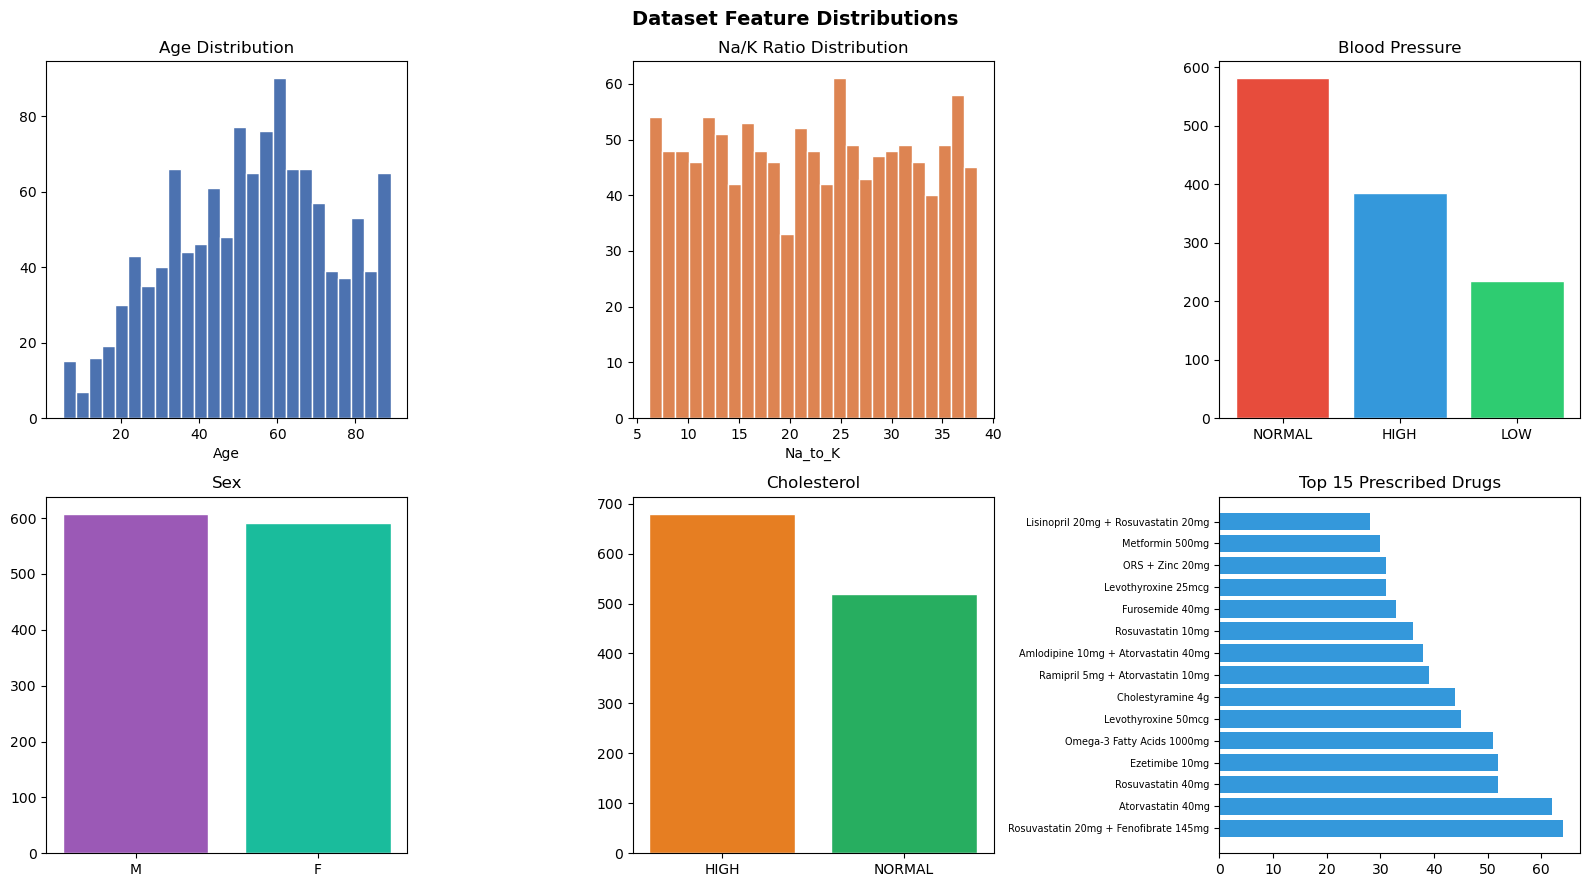

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dataset Feature Distributions', fontsize=14, fontweight='bold')

axes[0,0].hist(df['Age'], bins=25, color='#4C72B0', edgecolor='white')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')

axes[0,1].hist(df['Na_to_K'], bins=25, color='#DD8452', edgecolor='white')
axes[0,1].set_title('Na/K Ratio Distribution')
axes[0,1].set_xlabel('Na_to_K')

bp_c = df['BP'].value_counts()
axes[0,2].bar(bp_c.index, bp_c.values,
              color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[0,2].set_title('Blood Pressure')

sex_c = df['Sex'].value_counts()
axes[1,0].bar(sex_c.index, sex_c.values,
              color=['#9b59b6','#1abc9c'], edgecolor='white')
axes[1,0].set_title('Sex')

chol_c = df['Cholesterol'].value_counts()
axes[1,1].bar(chol_c.index, chol_c.values,
              color=['#e67e22','#27ae60'], edgecolor='white')
axes[1,1].set_title('Cholesterol')

top15 = df['Drug'].value_counts().head(15)
axes[1,2].barh(range(len(top15)), top15.values, color='#3498db')
axes[1,2].set_yticks(range(len(top15)))
axes[1,2].set_yticklabels(top15.index, fontsize=7)
axes[1,2].set_title('Top 15 Prescribed Drugs')

plt.tight_layout()
plt.show()

## Cell 6 — Na/K Ratio vs Drug (strongest predictor)

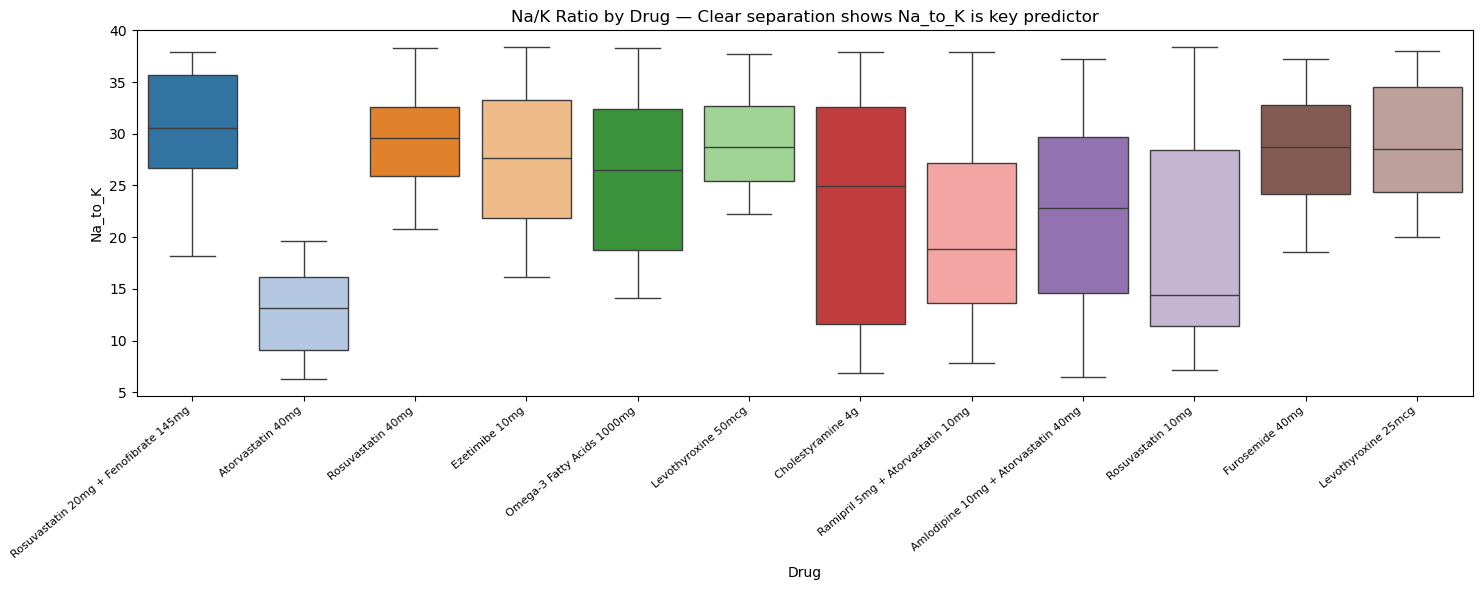

In [6]:
top12 = df['Drug'].value_counts().head(12).index
df_top = df[df['Drug'].isin(top12)]

plt.figure(figsize=(15, 6))
sns.boxplot(data=df_top, x='Drug', y='Na_to_K',
            order=top12, palette='tab20')
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.title('Na/K Ratio by Drug — Clear separation shows Na_to_K is key predictor', fontsize=12)
plt.tight_layout()
plt.show()

## Cell 7 — Encode Features & Define X, y

In [7]:
le_sex  = LabelEncoder()
le_bp   = LabelEncoder()
le_chol = LabelEncoder()
le_drug = LabelEncoder()

df['Sex_enc']  = le_sex.fit_transform(df['Sex'])
df['BP_enc']   = le_bp.fit_transform(df['BP'])
df['Chol_enc'] = le_chol.fit_transform(df['Cholesterol'])
df['Drug_enc'] = le_drug.fit_transform(df['Drug'])

print("Sex  :", dict(zip(le_sex.classes_,  le_sex.transform(le_sex.classes_).tolist())))
print("BP   :", dict(zip(le_bp.classes_,   le_bp.transform(le_bp.classes_).tolist())))
print("Chol :", dict(zip(le_chol.classes_, le_chol.transform(le_chol.classes_).tolist())))

FEATURES = ['Age', 'Sex_enc', 'BP_enc', 'Chol_enc', 'Na_to_K']

X = df[FEATURES].values
y = df['Drug_enc'].values

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {len(np.unique(y))}")

Sex  : {'F': 0, 'M': 1}
BP   : {'HIGH': 0, 'LOW': 1, 'NORMAL': 2}
Chol : {'HIGH': 0, 'NORMAL': 1}

X shape : (1200, 5)
y shape : (1200,)
Classes : 49


## Cell 8 — Train / Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y      # critical for 49 classes with small min-class size
)

print(f"Train : {X_train.shape[0]} samples ({100*len(X_train)/len(X):.0f}%)")
print(f"Test  : {X_test.shape[0]} samples ({100*len(X_test)/len(X):.0f}%)")

Train : 960 samples (80%)
Test  : 240 samples (20%)


## Cell 9 — Compare 6 Algorithms (5-fold CV)
> ⏳ Takes ~2–3 minutes

In [9]:
%pip install xgboost
import xgboost
print(xgboost.__version__)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
3.2.0


In [10]:
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Random Forest'     : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Extra Trees'       : ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost'           : XGBClassifier(n_estimators=200, random_state=42,
                                        eval_metric='mlogloss', verbosity=0),
    'Decision Tree'     : DecisionTreeClassifier(random_state=42),
    'KNN'               : KNeighborsClassifier(n_neighbors=5),
}

results = {}
print(f"{'Algorithm':<22}  {'CV Accuracy':>12}  {'Std':>8}")
print("-" * 46)
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    best_mark = " ← BEST" if scores.mean() == max(v.mean() for v in results.values()) else ""
    print(f"{name:<22}  {scores.mean()*100:>10.2f}%  ±{scores.std()*100:.2f}%{best_mark}")

best_name = max(results, key=lambda k: results[k].mean())
print(f"\n✅ Best: {best_name}  →  {results[best_name].mean()*100:.2f}% CV accuracy")

Algorithm                CV Accuracy       Std
----------------------------------------------
Random Forest                97.25%  ±0.62% ← BEST
Extra Trees                  89.83%  ±1.76%
Gradient Boosting            92.25%  ±1.76%
XGBoost                      94.33%  ±1.50%
Decision Tree                98.08%  ±1.07% ← BEST
KNN                          32.50%  ±1.12%

✅ Best: Decision Tree  →  98.08% CV accuracy


## Cell 10 — Plot Model Comparison

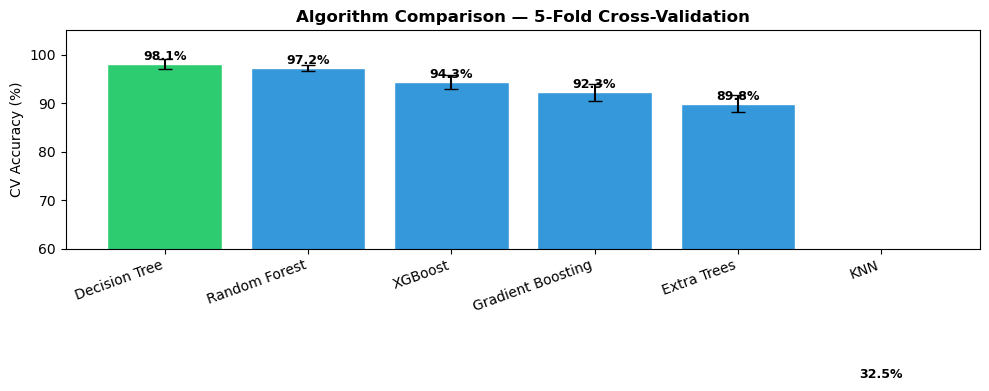

In [11]:
means = {k: v.mean()*100 for k, v in results.items()}
stds  = {k: v.std()*100  for k, v in results.items()}
names = sorted(means, key=means.get, reverse=True)
colors = ['#2ecc71' if n == best_name else '#3498db' for n in names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, [means[n] for n in names],
              yerr=[stds[n] for n in names],
              color=colors, capsize=5, edgecolor='white')
ax.set_ylim(60, 105)
ax.set_ylabel('CV Accuracy (%)')
ax.set_title('Algorithm Comparison — 5-Fold Cross-Validation', fontweight='bold')
plt.xticks(rotation=20, ha='right')
for bar, n in zip(bars, names):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f'{means[n]:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 11 — Hyperparameter Tuning (GridSearchCV)
> ⏳ Takes ~5–8 minutes

In [12]:
param_grid = {
    'n_estimators'     : [200, 300, 500],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 'log2'],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring = 'accuracy',
    n_jobs  = -1,
    verbose = 1
)
grid.fit(X_train, y_train)

print("\n✅ Best parameters:")
for k, v in grid.best_params_.items():
    print(f"   {k:<22}: {v}")
print(f"\nBest CV accuracy : {grid.best_score_*100:.2f}%")

best_model = grid.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best parameters:
   max_depth             : 10
   max_features          : sqrt
   min_samples_split     : 2
   n_estimators          : 200

Best CV accuracy : 96.98%


## Cell 12 — Evaluate on Test Set

In [13]:
y_pred   = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
cv_acc   = grid.best_score_

print("=" * 50)
print(f"  TEST ACCURACY  :  {test_acc*100:.2f}%")
print(f"  CV   ACCURACY  :  {cv_acc*100:.2f}%")
print("=" * 50)

y_test_names = le_drug.inverse_transform(y_test)
y_pred_names = le_drug.inverse_transform(y_pred)
print("\nClassification Report:")
print(classification_report(y_test_names, y_pred_names, zero_division=0))

  TEST ACCURACY  :  96.67%
  CV   ACCURACY  :  96.98%

Classification Report:
                                          precision    recall  f1-score   support

     Amlodipine 10mg + Atorvastatin 40mg       1.00      1.00      1.00         8
                        Amlodipine 2.5mg       1.00      0.33      0.50         3
                          Amlodipine 5mg       1.00      0.75      0.86         4
      Amlodipine 5mg + Atorvastatin 20mg       1.00      1.00      1.00         6
                           Aspirin 100mg       1.00      1.00      1.00         4
                            Aspirin 75mg       1.00      1.00      1.00         4
                       Atorvastatin 10mg       1.00      1.00      1.00         6
                       Atorvastatin 20mg       1.00      1.00      1.00         3
                       Atorvastatin 40mg       1.00      1.00      1.00        12
        Calcium + Vitamin D3 500mg/400IU       1.00      1.00      1.00         4
                 Ca

## Cell 13 — Confusion Matrix

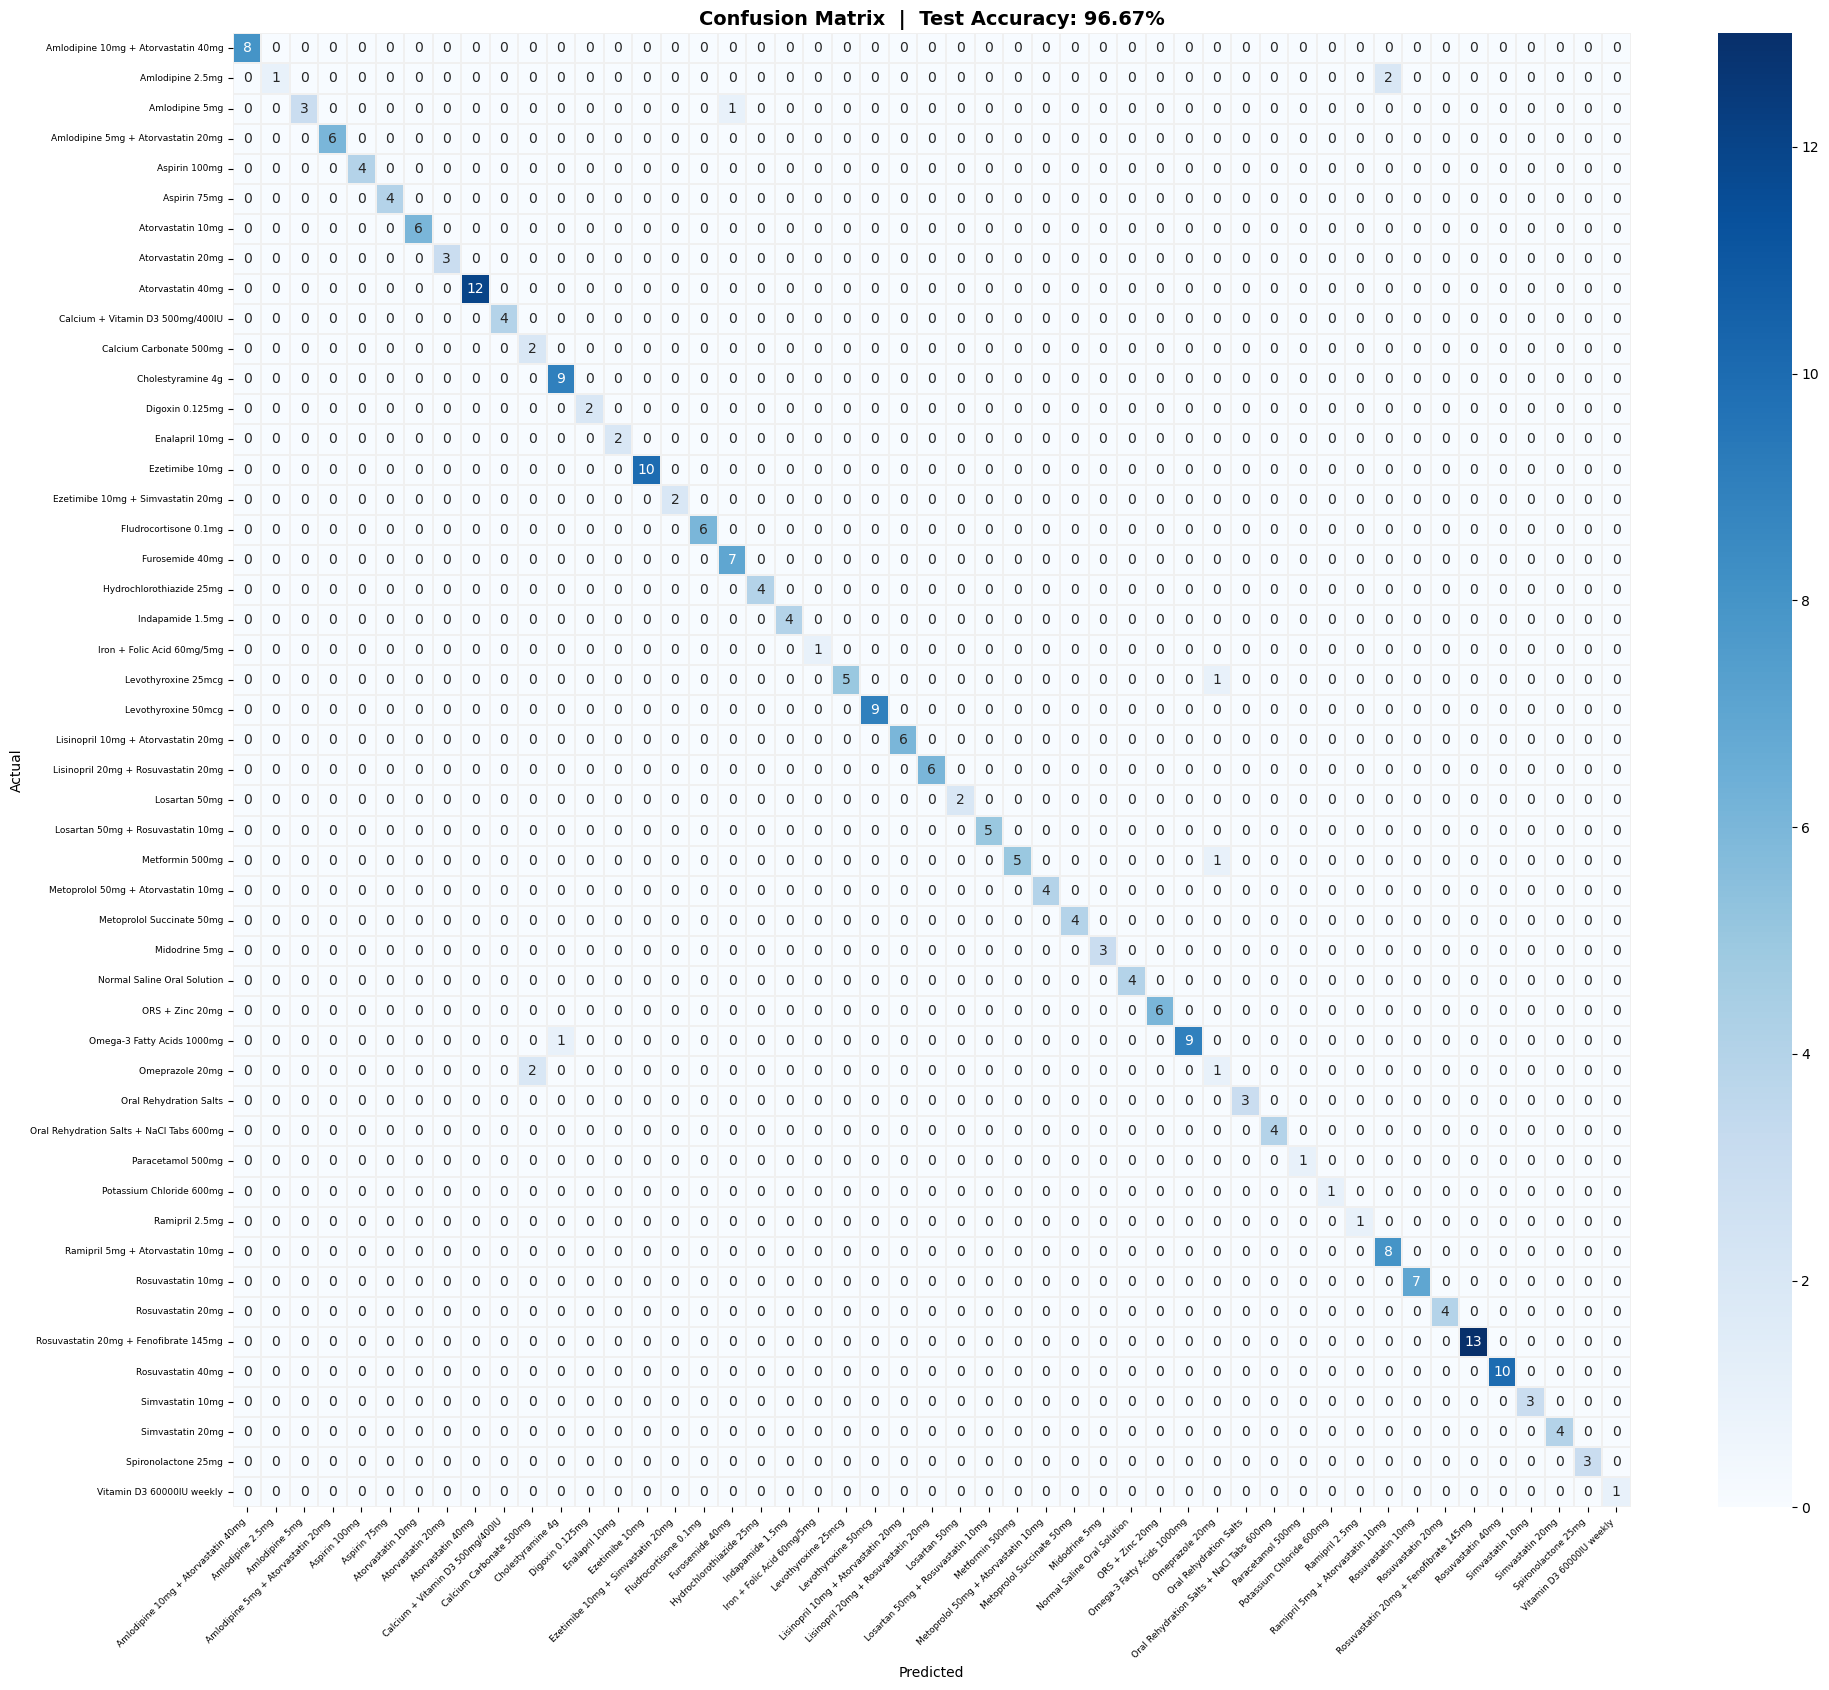

In [14]:
cm     = confusion_matrix(y_test, y_pred)
labels = le_drug.classes_

plt.figure(figsize=(20, 17))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels,
            annot=True, fmt='d', cmap='Blues',
            linewidths=0.3, linecolor='#f0f0f0')
plt.title(f'Confusion Matrix  |  Test Accuracy: {test_acc*100:.2f}%',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right', fontsize=6.5)
plt.yticks(fontsize=6.5)
plt.tight_layout()
plt.show()

## Cell 14 — Feature Importance

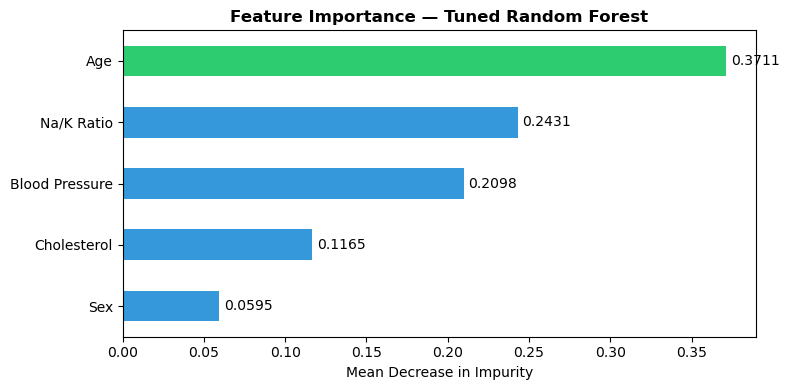


Feature ranking:
  Age                  0.3711  (37.1%)
  Na/K Ratio           0.2431  (24.3%)
  Blood Pressure       0.2098  (21.0%)
  Cholesterol          0.1165  (11.7%)
  Sex                  0.0595  (6.0%)


In [15]:
feat_names = ['Age', 'Sex', 'Blood Pressure', 'Cholesterol', 'Na/K Ratio']
importances = pd.Series(best_model.feature_importances_, index=feat_names)
importances = importances.sort_values(ascending=True)

colors = ['#2ecc71' if v == importances.max() else '#3498db' for v in importances]

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color=colors)
plt.title('Feature Importance — Tuned Random Forest', fontweight='bold')
plt.xlabel('Mean Decrease in Impurity')
for i, v in enumerate(importances):
    plt.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("\nFeature ranking:")
for name, val in importances.sort_values(ascending=False).items():
    print(f"  {name:<20} {val:.4f}  ({val*100:.1f}%)")

## Cell 15 — Save Model  *(generates drug_model.pkl)*

In [16]:
# Build drug info lookup from the dataset
drug_lookup = {}
for _, row in df.drop_duplicates('Drug').iterrows():
    drug_lookup[row['Drug']] = {
        'drug_class'  : row['DrugClass'],
        'indication'  : row['Indication'],
        'description' : row['DrugDescription'],
    }

bundle = {
    'model'         : best_model,
    'le_sex'        : le_sex,
    'le_bp'         : le_bp,
    'le_chol'       : le_chol,
    'le_drug'       : le_drug,
    'features'      : ['Age', 'Sex_enc', 'BP_enc', 'Chol_enc', 'Na_to_K'],
    'drug_lookup'   : drug_lookup,
    'test_accuracy' : test_acc,
    'cv_accuracy'   : cv_acc,
    'n_classes'     : int(len(le_drug.classes_)),
    'n_trees'       : int(best_model.n_estimators),
}

joblib.dump(bundle, 'drug_model.pkl')

print("✅ Saved  →  drug_model.pkl")
print(f"   Algorithm    : Random Forest ({best_model.n_estimators} trees)")
print(f"   Test Accuracy: {test_acc*100:.2f}%")
print(f"   CV Accuracy  : {cv_acc*100:.2f}%")
print(f"   Drug classes : {len(le_drug.classes_)}")
print(f"\n⚠️  Copy drug_model.pkl into the same folder as app.py before running Flask.")

✅ Saved  →  drug_model.pkl
   Algorithm    : Random Forest (200 trees)
   Test Accuracy: 96.67%
   CV Accuracy  : 96.98%
   Drug classes : 49

⚠️  Copy drug_model.pkl into the same folder as app.py before running Flask.


## Cell 16 — Predict a Single Patient

In [17]:
# ── Change these values to test ──────────────────────
new_patient = {
    'Age'        : 57,
    'Sex'        : 'F',       # 'M' or 'F'
    'BP'         : 'HIGH',    # 'HIGH', 'NORMAL', 'LOW'
    'Cholesterol': 'HIGH',    # 'HIGH' or 'NORMAL'
    'Na_to_K'   : 18.155,    # float  6.0 – 38.4
}
# ─────────────────────────────────────────────────────

bundle = joblib.load('drug_model.pkl')
X_new  = np.array([[
    new_patient['Age'],
    bundle['le_sex'].transform([new_patient['Sex']])[0],
    bundle['le_bp'].transform([new_patient['BP']])[0],
    bundle['le_chol'].transform([new_patient['Cholesterol']])[0],
    new_patient['Na_to_K'],
]])

pred_enc  = bundle['model'].predict(X_new)[0]
proba     = bundle['model'].predict_proba(X_new)[0]
drug_name = bundle['le_drug'].inverse_transform([pred_enc])[0]
conf      = max(proba) * 100
info      = bundle['drug_lookup'][drug_name]

print("=" * 60)
print(f"  PREDICTED DRUG : {drug_name}")
print(f"  DRUG CLASS     : {info['drug_class']}")
print(f"  INDICATION     : {info['indication']}")
print(f"  CONFIDENCE     : {conf:.1f}%")
print("=" * 60)
print(f"\nDescription:\n{info['description']}")

top3 = np.argsort(proba)[::-1][:3]
print("\nTop 3 predictions:")
for i, idx in enumerate(top3, 1):
    d = bundle['le_drug'].inverse_transform([idx])[0]
    print(f"  {i}. {d:<45} {proba[idx]*100:.1f}%")

  PREDICTED DRUG : Lisinopril 10mg + Atorvastatin 20mg
  DRUG CLASS     : ACE Inhibitor + Statin
  INDICATION     : Mid-age hypertension + dyslipidemia
  CONFIDENCE     : 95.2%

Description:
Combination of ACE inhibitor Lisinopril 10mg and moderate-intensity statin Atorvastatin 20mg for simultaneous management of hypertension and dyslipidemia. Lisinopril inhibits ACE to block angiotensin II-mediated vasoconstriction, reducing blood pressure and providing renal protection in diabetic patients. Atorvastatin reduces LDL cholesterol by 38–46%. Together, they address two major independent cardiovascular risk factors, significantly reducing 10-year cardiovascular event risk in patients with both high BP and high cholesterol.

Top 3 predictions:
  1. Lisinopril 10mg + Atorvastatin 20mg           95.2%
  2. Losartan 50mg + Rosuvastatin 10mg             2.6%
  3. Amlodipine 5mg + Atorvastatin 20mg            0.8%
